<a href="https://colab.research.google.com/github/Kashyyaap/AI-ML_Internship/blob/main/DAY_3(part_b).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

In [72]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [73]:
df.shape


(6435, 8)

In [74]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [75]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [76]:
df.isnull().sum()


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [77]:
df.nunique()

,0
Store,45
Date,143
Weekly_Sales,6435
Holiday_Flag,2
Temperature,3528
Fuel_Price,892
CPI,2145
Unemployment,349


In [78]:
df.duplicated().sum()

np.int64(0)

<Axes: >

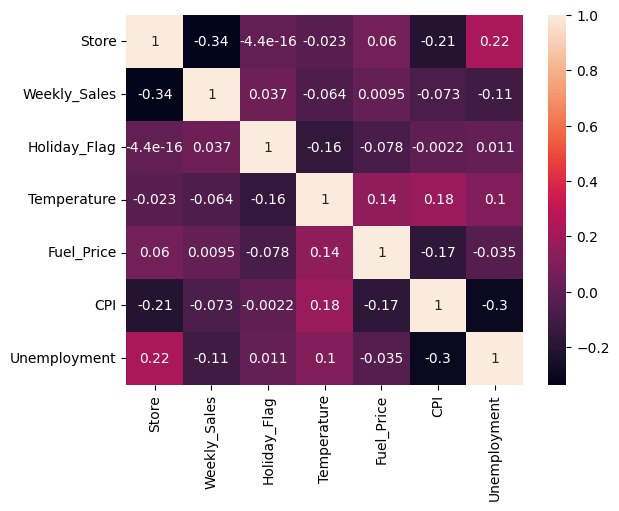

In [79]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

<Axes: xlabel='Date'>

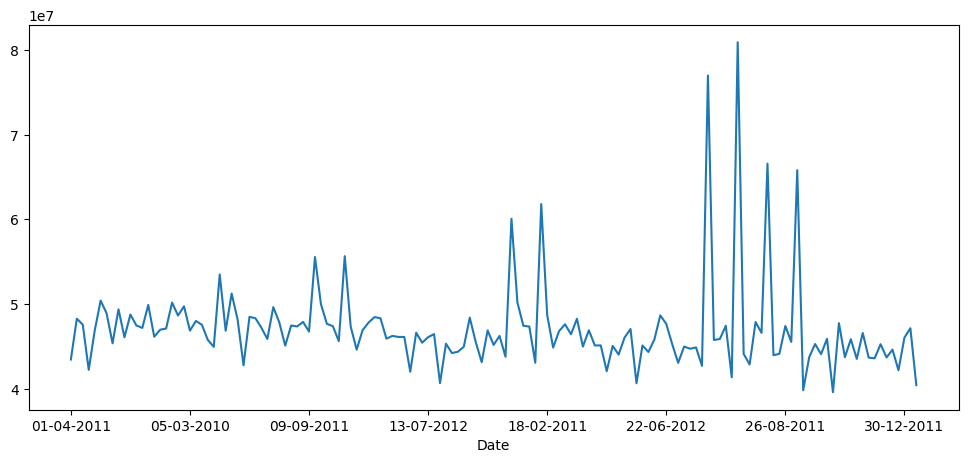

In [80]:
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5))

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

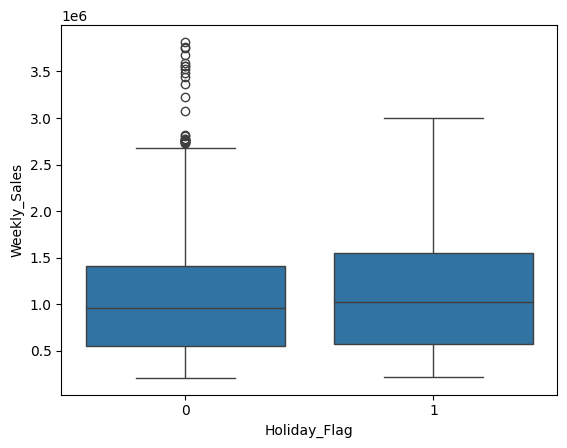

In [81]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

<Axes: xlabel='Store'>

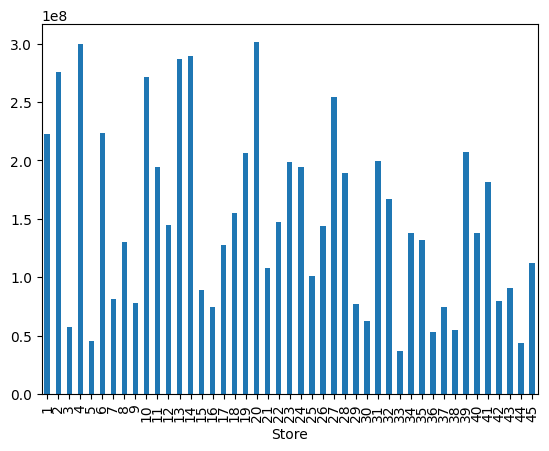

In [82]:
df.groupby('Store')['Weekly_Sales'].sum().plot(kind='bar')

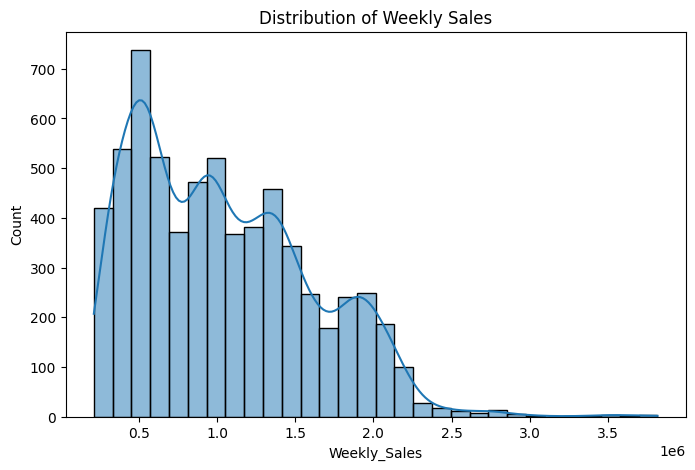

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(
df['Weekly_Sales'],
bins=30,
kde=True
)

plt.title("Distribution of Weekly Sales")
plt.show()

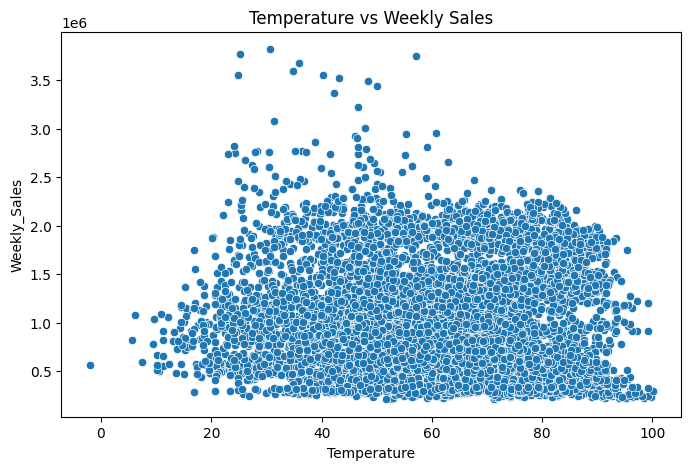

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(
x='Temperature',
y='Weekly_Sales',
data=df
)

plt.title("Temperature vs Weekly Sales")
plt.show()

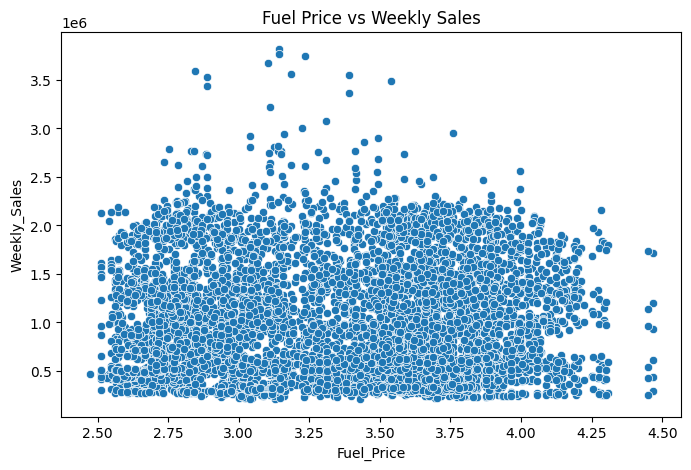

In [85]:
plt.figure(figsize=(8,5))
sns.scatterplot(
x='Fuel_Price',
y='Weekly_Sales',
data=df
)

plt.title("Fuel Price vs Weekly Sales")
plt.show()

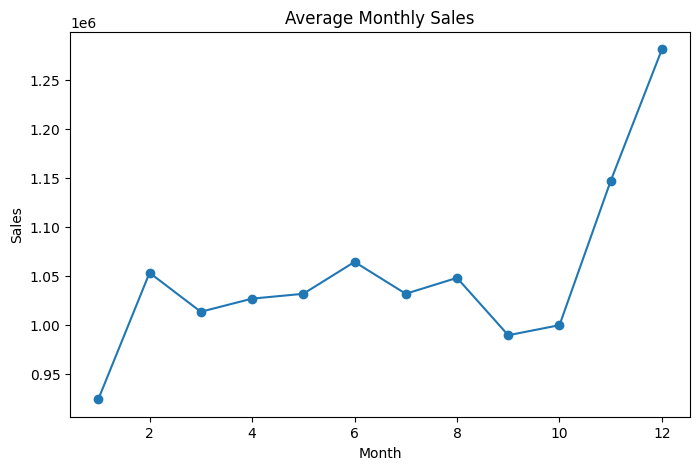

In [86]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')

plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.show()

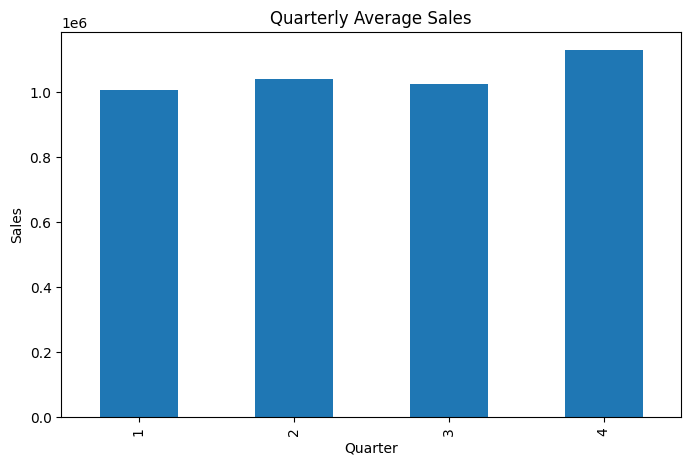

In [87]:
df['Quarter'] = df['Date'].dt.quarter
quarterly_sales = df.groupby('Quarter')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
quarterly_sales.plot(kind='bar')

plt.title("Quarterly Average Sales")
plt.ylabel("Sales")
plt.show()

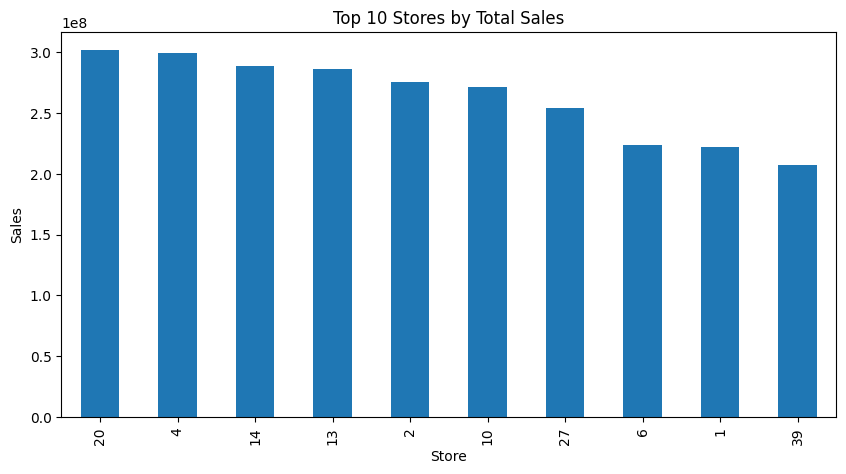

In [88]:
top10 = (df.groupby('Store')['Weekly_Sales']
           .sum()
           .sort_values(ascending=False)
           .head(10))

plt.figure(figsize=(10,5))
top10.plot(kind='bar')

plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Sales")
plt.show()

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

X = df.drop(["Weekly_Sales", "Date"], axis=1)
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 57538.00
RMSE : 114064.01
R²   : 0.9596


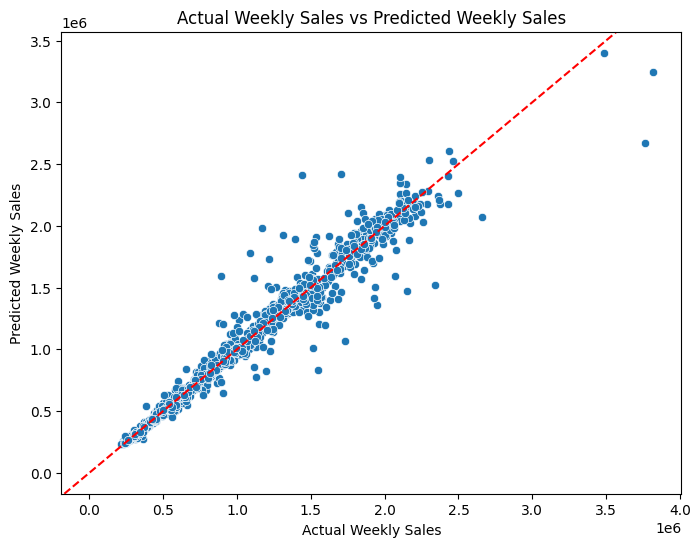

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual Weekly Sales vs Predicted Weekly Sales")
plt.axline([0,0],[1,1],color="red",linestyle
           ="--")
plt.show()

In [91]:
from scipy.stats import skew
skewness = df.skew(numeric_only=True)
num_cols = len(df.columns)
print(skewness)

Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
Month           0.039568
Quarter         0.011203
Year            0.062642
Day             0.008512
dtype: float64


In [92]:
import numpy as np
skewed_cols = df.skew(numeric_only=True).abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("Highly Skewed Columns: \n ",highly_skewed)
print("Negatively Skewed Columns: \n ",negatively_skewed)

Highly Skewed Columns: 
  Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns: 
  Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Month',
       'Quarter', 'Year', 'Day'],
      dtype='object')


In [93]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

from sklearn.preprocessing import PowerTransformer

negatively_skewed_features_list = [col for col in negatively_skewed if col != 'Weekly_Sales']
pt_features = PowerTransformer(method="yeo-johnson")
df[negatively_skewed_features_list] = pt_features.fit_transform(df[negatively_skewed_features_list])

pt_target = PowerTransformer(method="yeo-johnson")
df['Weekly_Sales'] = pt_target.fit_transform(df[['Weekly_Sales']])

In [94]:

X = df.drop(["Weekly_Sales", "Date"], axis=1)
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.09
RMSE : 0.15
R²   : 0.9766


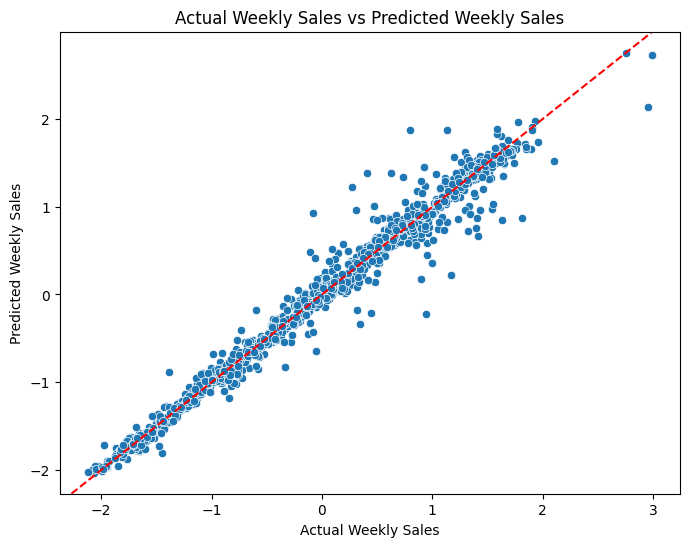

In [95]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual Weekly Sales vs Predicted Weekly Sales")
plt.axline([0,0],[1,1],color="red",linestyle
           ="--")
plt.show()

In [100]:
sample_input_data = pd.DataFrame([{
    'Store': 1,
    'Holiday_Flag': 1,
    'Temperature': 38.51,
    'Fuel_Price': 2.548,
    'CPI':211.242170,
    'Unemployment': 8.106,
    'Year': 2010,
    'Month': 2,
    'Day': 12,
    'Quarter': 1

}])

sample_input_data[highly_skewed] = sample_input_data[highly_skewed].apply(lambda x: np.log1p(x))

features_for_pt = ['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Month', 'Quarter', 'Year', 'Day']
sample_input_data[features_for_pt] = pt_features.transform(sample_input_data[features_for_pt])
sample_input_data = sample_input_data[X_train.columns]
predicted_sales_transformed = rf.predict(sample_input_data)

original_scale_prediction = pt_target.inverse_transform(predicted_sales_transformed.reshape(-1, 1))[0][0]

print(f"Predicted Weekly Sales (Original Scale): {original_scale_prediction:.2f}")

Predicted Weekly Sales (Original Scale): 1617433.39


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
